In [6]:
import matplotlib.lines as mlines
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats as stats
from scipy.optimize import curve_fit

plt.style.use("default")

resultsdir = "../2_structure_prediction/parsed_results"

df_esm = pd.read_csv(f"{resultsdir}/af_res_esmfold_info.csv", index_col=0)
df_colabfold = pd.read_csv(f"{resultsdir}/af_res_colabfold_info.csv", index_col=0)
df_af3 = pd.read_csv(f"{resultsdir}/af_res_af3_info.csv", index_col=0)

wrdm_esm = pd.read_csv(f"{resultsdir}/rdm_esmfold_info.csv", index_col=0)
wrdm_colabfold = pd.read_csv(f"{resultsdir}/rdm_colabfold_info.csv", index_col=0)
wrdm_af3 = pd.read_csv(f"{resultsdir}/rdm_af3_info.csv", index_col=0)

sp_esm = pd.read_csv(f"{resultsdir}/sp_res_esmfold_info.csv", index_col=0)
sp_colabfold = pd.read_csv(f"{resultsdir}/sp_res_colabfold_info.csv", index_col=0)
sp_af3 = pd.read_csv(f"{resultsdir}/sp_res_af3_info.csv", index_col=0)

# annotate with swissprot info
sp_info_file = "../../data/swiss-prot/2025_03_uniprot_sprot_anno.tsv"
sp_info = pd.read_csv(sp_info_file, index_col=0, sep="\t")

In [7]:
af_dfs = [df_esm, df_colabfold, df_af3]
for df in af_dfs:
    print(len(df))

sp_dfs = [sp_esm, sp_colabfold, sp_af3]
for df in sp_dfs:
    print(len(df))
rdm_dfs = [wrdm_esm, wrdm_colabfold, wrdm_af3]
for df in rdm_dfs:
    print(len(df))

763
763
763
80
80
80
80
80
80


In [8]:
df_esm["pae pTM"] = "0"
sp_esm["pae pTM"] = "0"
wrdm_esm["pae pTM"] = "0"

In [9]:
def annotate_dfs(esm, colabfold, af3):
    esm["method"] = "ESMFold"
    colabfold["method"] = "AlphaFold2"
    af3["method"] = "AlphaFold3"
    return esm, colabfold, af3


df_esm, df_colabfold, df_af3 = annotate_dfs(df_esm, df_colabfold, df_af3)
wrdm_esm, wrdm_colabfold, wrdm_af3 = annotate_dfs(wrdm_esm, wrdm_colabfold, wrdm_af3)
sp_esm, sp_colabfold, sp_af3 = annotate_dfs(sp_esm, sp_colabfold, sp_af3)

# fig 1: plddt length, ptm length

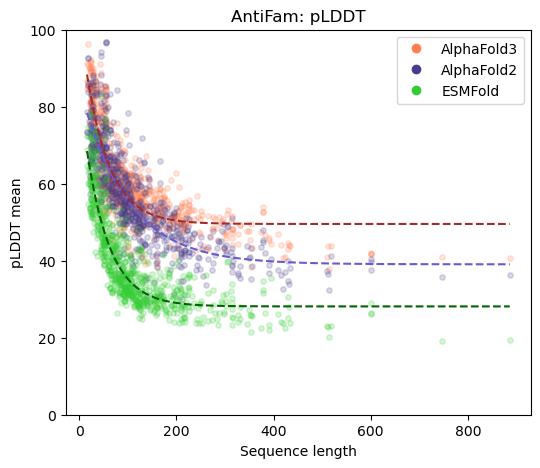

In [10]:
# combined sequence length plot
def equation(x, a, b, c):
    max_exp = 709
    clipped_values = np.clip(-b * x, -max_exp, max_exp)
    result = a * np.exp(clipped_values) + c
    return result


def plot_curve(data, colour, plot_ax):
    data = data.sort_values(by=["length"])
    length = np.array(data["length"], dtype=np.float128)
    pl_mean = np.array(data["pLDDT mean"], dtype=np.float128)

    p, cov = curve_fit(equation, length, pl_mean)
    a_expo, b_expo, c_expo = p

    x_line = np.linspace(start=min(length), stop=max(length), num=pl_mean.size)
    y_model = equation(x_line, a_expo, b_expo, c_expo)

    plot_ax.plot(x_line, y_model, "--", color=colour, linewidth=1.5, alpha=1)


def combined_sequence_length(esm, colabfold, af3, title):
    handles = [
        mlines.Line2D(
            [],
            [],
            color="coral",
            marker="o",
            linestyle="None",
            markersize=6,
            label="AlphaFold3",
            alpha=1.0,
        ),
        mlines.Line2D(
            [],
            [],
            color="darkslateblue",
            marker="o",
            linestyle="None",
            markersize=6,
            label="AlphaFold2",
            alpha=1.0,
        ),
        mlines.Line2D(
            [],
            [],
            color="limegreen",
            marker="o",
            linestyle="None",
            markersize=6,
            label="ESMFold",
            alpha=1.0,
        ),
    ]

    fig, ax = plt.subplots(figsize=(6, 5))
    plt.xlabel("Sequence length")
    plt.ylabel("pLDDT mean")
    plt.scatter(
        af3["length"], af3["pLDDT mean"], label="AlphaFold3", s=15, c="coral", alpha=0.2
    )
    plt.scatter(
        colabfold["length"],
        colabfold["pLDDT mean"],
        label="AlphaFold2",
        s=15,
        c="darkslateblue",
        alpha=0.2,
    )
    plt.scatter(
        esm["length"],
        esm["pLDDT mean"],
        label="ESMFold",
        s=15,
        c="limegreen",
        alpha=0.2,
    )
    ax.set_yticks(np.linspace(0, 100, 6))

    ax.set_ylim(0, 100)

    plot_curve(esm, "darkgreen", ax)
    plot_curve(colabfold, "slateblue", ax)
    plot_curve(af3, "brown", ax)
    plt.legend(loc="upper right", handles=handles)
    plt.title(title)


combined_sequence_length(df_esm, df_colabfold, df_af3, "AntiFam: pLDDT")

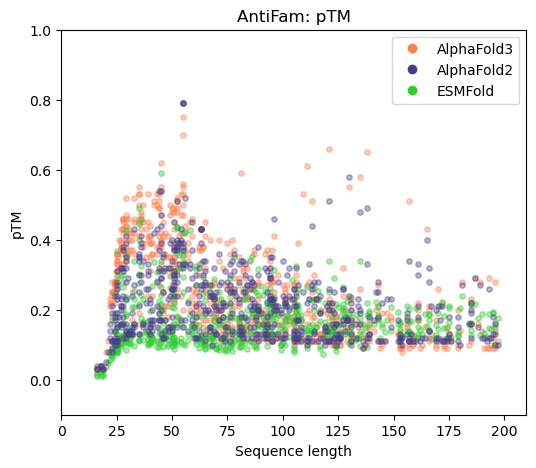

In [11]:
# short sequence length vs ptm
def combined_seq_ptm(esm, colabfold, af3, title):
    handles = [
        mlines.Line2D(
            [],
            [],
            color="coral",
            marker="o",
            linestyle="None",
            markersize=6,
            label="AlphaFold3",
            alpha=1.0,
        ),
        mlines.Line2D(
            [],
            [],
            color="darkslateblue",
            marker="o",
            linestyle="None",
            markersize=6,
            label="AlphaFold2",
            alpha=1.0,
        ),
        mlines.Line2D(
            [],
            [],
            color="limegreen",
            marker="o",
            linestyle="None",
            markersize=6,
            label="ESMFold",
            alpha=1.0,
        ),
    ]

    fig, ax = plt.subplots(figsize=(6, 5))
    short_esm = esm[esm["length"] < 200]
    short_colabfold = colabfold[colabfold["length"] < 200]
    short_af3 = af3[af3["length"] < 200]

    plt.xlabel("Sequence length")
    plt.ylabel("pTM")
    ax.set_yticks(np.linspace(0, 1.0, 6))
    ax.set_xticks(range(0, 210, 25))
    ax.set_ylim(-0.1, 1.0)
    ax.set_xlim(0, 210)
    plt.scatter(
        short_af3["length"],
        short_af3["pTM"],
        label="AlphaFold3",
        s=15,
        c="coral",
        alpha=0.4,
    )
    plt.scatter(
        short_esm["length"],
        short_esm["pTM"],
        label="ESMFold",
        s=15,
        c="limegreen",
        alpha=0.4,
    )
    plt.scatter(
        short_colabfold["length"],
        short_colabfold["pTM"],
        label="AlphaFold2",
        s=15,
        c="darkslateblue",
        alpha=0.4,
    )

    plt.legend(loc="upper right", handles=handles)
    plt.title(title)


combined_seq_ptm(df_esm, df_colabfold, df_af3, "AntiFam: pTM")


AlphaFold3 pLDDT-pTM p-value: 3.2399e-91, Std err: 0.0003, R²: 0.417
AlphaFold2 pLDDT-pTM p-value: 6.7268e-63, Std err: 0.0002, R²: 0.308
ESMFold pLDDT-pTM p-value: 1.1575e-12, Std err: 0.0002, R²: 0.064


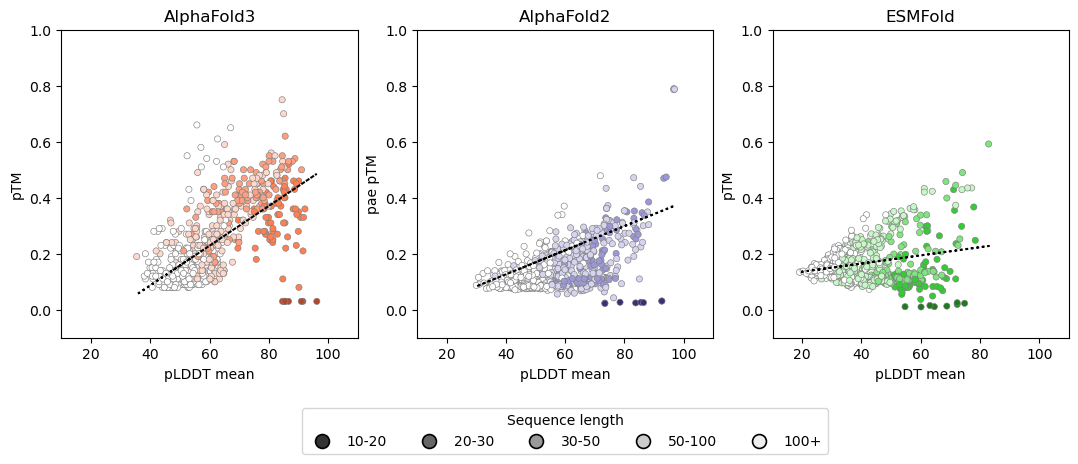

In [12]:
figure, axis = plt.subplots(1, 3, figsize=(13, 4))

bins = [10, 20, 30, 50, 100, np.inf]
labels = ["10–20", "20–30", "30–50", "50–100", "100+"]


model_colors = {
    "AlphaFold3": [
        "#b3472d",
        "#ff7f50",
        "#ff9f80",
        "#ffd8cc",
        "#ffffff",
    ],
    "AlphaFold2": [
        "#3b2f77",
        "#d6d4ef",
        "#9c98d6",
        "#d6d4ef",
        "#ffffff",
    ],
    "ESMFold": [
        "#1f7a1f",
        "#32cd32",
        "#7fe57f",
        "#c8f7c8",
        "#ffffff",
    ],
}


def sub_scatter(index_num, data, model_name, ptmtype="ptm"):
    ax = axis[index_num]
    base_colors = model_colors[model_name]

    data["length_bin"] = pd.cut(data["length"], bins=bins, labels=labels, right=False)

    color_mapping = dict(zip(labels, base_colors))
    point_colors = data["length_bin"].map(color_mapping)

    m, b = np.polyfit(data["pLDDT mean"], data["pTM"], deg=1)
    regression_line = m * data["pLDDT mean"] + b

    ax.set_xlabel("pLDDT mean")
    if ptmtype == "altptm":
        ax.set_ylabel("pae pTM")
    else:
        ax.set_ylabel("pTM")
    ax.set_title(f"{model_name}")
    ax.set_yticks(np.linspace(0, 1.0, 6))
    ax.set_xticks(range(20, 110, 20))
    ax.set_xlim(10, 110)
    ax.set_ylim(-0.1, 1.0)
    if ptmtype == "altptm":
        ax.scatter(
            data["pLDDT mean"],
            data["pae pTM"],
            s=20,
            c=point_colors,
            edgecolors="grey",
            linewidth=0.45,
        )
    else:
        ax.scatter(
            data["pLDDT mean"],
            data["pTM"],
            s=20,
            c=point_colors,
            edgecolors="grey",
            linewidth=0.45,
        )

    greys = ["#333333", "#666666", "#999999", "#cccccc", "#eeeeee"]

    legend_labels = ["10-20", "20-30", "30-50", "50-100", "100+"]

    handles = [
        mlines.Line2D(
            [0],
            [0],
            marker="o",
            color="k",
            markerfacecolor=grey,
            markeredgewidth=1.2,
            markeredgecolor="black",
            markersize=10,
            linestyle="None",
        )
        for grey in greys
    ]

    if index_num == 2:
        ax.legend(
            handles=handles,
            labels=legend_labels,
            title="Sequence length",
            loc="lower center",
            bbox_to_anchor=(-0.70, -0.4),
            ncol=len(handles),
            frameon=True,
        )

    ax.plot(data["pLDDT mean"], regression_line, linestyle=":", lw=1.5, color="black")
    slope, intercept, r_value, p_value, std_err = stats.linregress(
        data["pLDDT mean"], data["pTM"]
    )
    print(
        f"{model_name} pLDDT-pTM p-value: {p_value:.4e}, Std err: {std_err:.4f}, R²: {r_value**2:.3f}"
    )


sub_scatter(0, df_af3, "AlphaFold3")
sub_scatter(1, df_colabfold, "AlphaFold2", "altptm")
sub_scatter(2, df_esm, "ESMFold")

plt.show()

# Fig 2 - combined

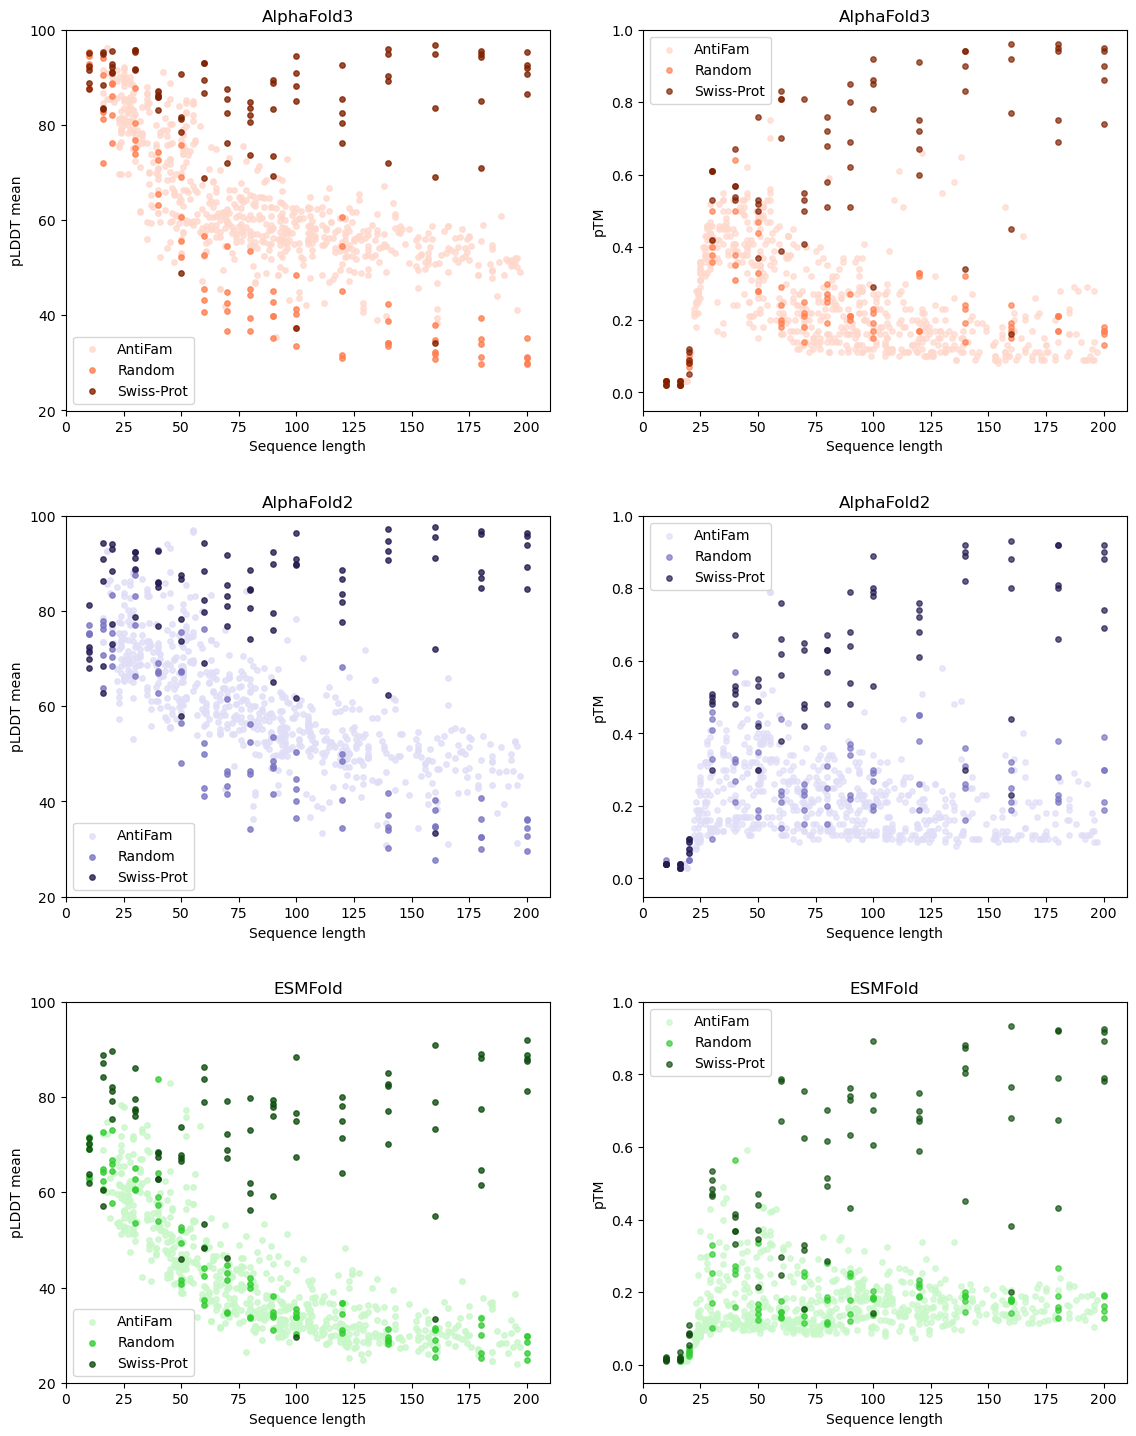

In [13]:
COLOUR_MAP = {
    "AlphaFold2": {"AntiFam": "#e0def7", "Random": "#7a75c2", "Swiss-Prot": "#241b4f"},
    "AlphaFold3": {"AntiFam": "#ffd8cc", "Random": "#ff7f50", "Swiss-Prot": "#802100"},
    "ESMFold": {"AntiFam": "#c8f7c8", "Random": "#32cd32", "Swiss-Prot": "#0f4d0f"},
}


def plot_pLDDT(ax, antifam_df, random_df, swissprot_df, model_name, size=15, alpha=0.8):
    short_antifam = antifam_df[antifam_df["length"] < 200]

    # Get colors for this model
    colors = COLOUR_MAP[model_name]

    # Plot each dataset
    ax.scatter(
        short_antifam["length"],
        short_antifam["pLDDT mean"],
        label="AntiFam",
        s=size,
        c=colors["AntiFam"],
        alpha=alpha,
    )
    ax.scatter(
        random_df["length"],
        random_df["pLDDT mean"],
        label="Random",
        s=size,
        c=colors["Random"],
        alpha=alpha,
    )
    ax.scatter(
        swissprot_df["length"],
        swissprot_df["pLDDT mean"],
        label="Swiss-Prot",
        s=size,
        c=colors["Swiss-Prot"],
        alpha=alpha,
    )

    # Format axes
    ax.set_ylabel("pLDDT mean")
    ax.set_xlabel("Sequence length")
    ax.set_yticks(np.linspace(20, 100, 5))
    ax.set_ylim(20, 100)
    ax.set_xlim(0, 210)
    ax.set_xticks(range(0, 210, 25))
    ax.set_title(model_name)


def plot_pTM(
    ax,
    antifam_df,
    random_df,
    swissprot_df,
    model_name,
    ptm_type="pTM",
    size=15,
    alpha=0.7,
):
    short_antifam = antifam_df[antifam_df["length"] < 200]

    colors = COLOUR_MAP[model_name]

    ax.scatter(
        short_antifam["length"],
        short_antifam[ptm_type],
        label="AntiFam",
        s=size,
        c=colors["AntiFam"],
        alpha=alpha,
    )
    ax.scatter(
        random_df["length"],
        random_df[ptm_type],
        label="Random",
        s=size,
        c=colors["Random"],
        alpha=alpha,
    )
    ax.scatter(
        swissprot_df["length"],
        swissprot_df[ptm_type],
        label="Swiss-Prot",
        s=size,
        c=colors["Swiss-Prot"],
        alpha=alpha,
    )

    ax.set_ylabel(ptm_type)
    ax.set_xlabel("Sequence length")
    ax.set_yticks(np.linspace(0, 1, 6))
    ax.set_ylim(-0.05, 1)
    ax.set_xlim(0, 210)
    ax.set_xticks(range(0, 210, 25))
    ax.set_title(model_name)


def plot_all_comparisons(
    af2_data, af3_data, esm_data, ptm_type="pTM", figsize=(12, 15)
):
    af2_antifam, af2_random, af2_swissprot = af2_data
    af3_antifam, af3_random, af3_swissprot = af3_data
    esm_antifam, esm_random, esm_swissprot = esm_data

    fig, axes = plt.subplots(3, 2, figsize=figsize)

    plot_pLDDT(axes[0, 0], af3_antifam, af3_random, af3_swissprot, "AlphaFold3")
    plot_pTM(
        axes[0, 1],
        af3_antifam,
        af3_random,
        af3_swissprot,
        "AlphaFold3",
        ptm_type=ptm_type,
    )

    plot_pLDDT(axes[1, 0], af2_antifam, af2_random, af2_swissprot, "AlphaFold2")
    plot_pTM(
        axes[1, 1],
        af2_antifam,
        af2_random,
        af2_swissprot,
        "AlphaFold2",
        ptm_type=ptm_type,
    )

    plot_pLDDT(axes[2, 0], esm_antifam, esm_random, esm_swissprot, "ESMFold")
    plot_pTM(
        axes[2, 1], esm_antifam, esm_random, esm_swissprot, "ESMFold", ptm_type=ptm_type
    )

    for i in range(3):
        axes[i, 0].legend(loc="lower left")
        axes[i, 1].legend(loc="upper left")

    plt.tight_layout(pad=3.0)
    plt.show()


plot_all_comparisons(
    af2_data=(df_colabfold, wrdm_colabfold, sp_colabfold),
    af3_data=(df_af3, wrdm_af3, sp_af3),
    esm_data=(df_esm, wrdm_esm, sp_esm),
    ptm_type="pTM",
    figsize=(12, 15),
)

In [14]:
af3_lowsp = sp_af3[(sp_af3["length"] > 50) & (sp_af3["pLDDT mean"] < 65)]
colabfold_lowsp = sp_colabfold[
    (sp_colabfold["length"] > 50) & (sp_colabfold["pLDDT mean"] < 65)
]
esm_lowsp = sp_esm[(sp_esm["length"] > 50) & (sp_esm["pLDDT mean"] < 50)]


def annotate(info_df, df):
    df_reset = df.reset_index()
    merged = df_reset.merge(
        info_df[
            [
                "name",
                "caution",
                "is_bacteria",
                "iupred_average",
                "annotation_score",
                "protein_existence_score",
                "Pfam count",
                "MobiDB count",
            ]
        ],
        left_on="index",
        right_on="uniprot_id",
        how="left",
    )
    return merged

In [15]:
print(annotate(sp_info, esm_lowsp))

    index  length  pLDDT mean    pTM pae pTM   method  \
0  B8GJW5      60        48.4  0.248       0  ESMFold   
1  P0CX99     160        33.3  0.200       0  ESMFold   
2  P44107      70        46.2  0.152       0  ESMFold   
3  Q12115     100        29.6  0.141       0  ESMFold   

                                       name  \
0      Large ribosomal subunit protein eL37   
1          UPF0479 membrane protein YFL068W   
2           Uncharacterized protein HI_1063   
3  Putative uncharacterized protein YDL016C   

                                             caution is_bacteria  \
0                                                NaN          No   
1                                                NaN          No   
2                                                NaN         Yes   
3  Product of a dubious gene prediction unlikely ...          No   

   iupred_average  annotation_score    protein_existence_score  Pfam count  \
0        0.427092               2.0  3: Inferred from homol

In [16]:
print(annotate(sp_info, af3_lowsp))

    index  length  pLDDT mean   pTM  max pae   mean pae   pae pTM      method  \
0  P0CX99     160   34.149605  0.16     31.5  23.209551  0.308236  AlphaFold3   
1  Q12115     100   37.405825  0.29     31.0  19.036760  0.436322  AlphaFold3   

                                       name  \
0          UPF0479 membrane protein YFL068W   
1  Putative uncharacterized protein YDL016C   

                                             caution is_bacteria  \
0                                                NaN          No   
1  Product of a dubious gene prediction unlikely ...          No   

   iupred_average  annotation_score    protein_existence_score  Pfam count  \
0        0.049225               2.0  3: Inferred from homology         0.0   
1        0.077198               1.0               5: Uncertain         0.0   

   MobiDB count  
0           0.0  
1           0.0  


In [17]:
print(annotate(sp_info, colabfold_lowsp))

    index  length  pLDDT mean   pTM    max pae   mean pae   pae pTM  \
0  Q12115     100   61.773800  0.53  27.078125  11.082517  0.409124   
1  P0CX99     160   33.331313  0.23  30.078125  20.441639  0.147893   
2  Q6CBQ8     140   62.440714  0.30  31.109375  19.130662  0.233881   

       method                                              name  \
0  AlphaFold2          Putative uncharacterized protein YDL016C   
1  AlphaFold2                  UPF0479 membrane protein YFL068W   
2  AlphaFold2  Respiratory supercomplex factor 1, mitochondrial   

                                             caution is_bacteria  \
0  Product of a dubious gene prediction unlikely ...          No   
1                                                NaN          No   
2                                                NaN          No   

   iupred_average  annotation_score    protein_existence_score  Pfam count  \
0        0.077198               1.0               5: Uncertain         0.0   
1        0.049225

In [28]:
# high pTM antifams
top_pTM_af3 = df_af3.sort_values(by="pTM", ascending=False).head(10)
top_pTM_af2 = df_colabfold.sort_values(by="pTM", ascending=False).head(10)
top_pTM_esm = df_esm.sort_values(by="pTM", ascending=False).head(10)

print(top_pTM_af2)
print(top_pTM_af3)
print(top_pTM_esm)

                length  pLDDT mean   pTM    max pae   mean pae   pae pTM  \
ANF00264_seq_3      55   96.919636  0.79  17.234375   2.535421  0.787745   
ANF00264_seq_1      55   96.715091  0.79  18.312500   2.606241  0.789612   
ANF00264_seq_2      55   96.640727  0.79  17.453125   2.629970  0.785872   
ANF00269_seq_3     130   71.886615  0.58  30.828125  11.431347  0.478584   
ANF00189_seq_2      45   93.287778  0.54  28.843750   5.218015  0.469646   
ANF00181_seq_1      44   94.092045  0.54  26.562500   5.112040  0.473987   
ANF00138_seq_3      56   83.144643  0.52  30.781250  10.712436  0.471612   
ANF00215_seq_1      52   85.446154  0.51  29.062500   8.991590  0.440478   
ANF00270_seq_2     121   59.676116  0.51  29.687500  12.504571  0.370172   
ANF00269_seq_1     138   58.945580  0.49  30.562500  12.543028  0.339654   

                    method  
ANF00264_seq_3  AlphaFold2  
ANF00264_seq_1  AlphaFold2  
ANF00264_seq_2  AlphaFold2  
ANF00269_seq_3  AlphaFold2  
ANF00189_seq_2  Al